<a href="https://colab.research.google.com/github/cceballosbedoya-dev/Ciencia-datos-curso/blob/main/analisis_esperanza_vida_who_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Preparación del entorno

Antes de tocar los datos se dejan fijas las versiones mínimas y la configuración de las gráficas. Esto evita el clásico problema de "en mi máquina sí corría": si alguien más abre este notebook con una versión vieja de scikit-learn, el assert lo va a frenar ahí mismo en vez de fallar más adelante con un error críptico.

In [7]:
import sys
# Se valida la versión de Python porque algunas funciones de sklearn y pandas usadas
# más adelante (f-strings, sintaxis de type hints en librerías internas) requieren 3.7+
assert sys.version_info >= (3, 7), "Se requiere Python 3.7 o superior para este notebook"

from packaging import version
import sklearn
# Se fija un piso de versión de scikit-learn porque SGDRegressor, PolynomialFeatures
# y las curvas de aprendizaje que se usan aquí cambiaron de comportamiento entre versiones
assert version.parse(sklearn.__version__) >= version.parse("1.0.1"), "Se requiere scikit-learn >= 1.0.1"

print(f"Python {sys.version.split()[0]} | scikit-learn {sklearn.__version__}")

Python 3.12.13 | scikit-learn 1.6.1


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Semilla fija para que el split, el ruido del SGD y cualquier muestreo aleatorio
# sean reproducibles: si se vuelve a correr el notebook, los números no deberían moverse
np.random.seed(42)

# Se ajusta el tamaño de fuente por defecto porque las gráficas por defecto de matplotlib
# quedan ilegibles cuando se exportan o se proyectan
plt.rc('font', size=13)
plt.rc('axes', labelsize=13, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rc('figure', figsize=(9, 5))

In [9]:
from pathlib import Path

# Carpeta donde se guardan las figuras generadas, separada del resto del proyecto
# para no ensuciar el directorio raíz con decenas de PNG
IMAGES_PATH = Path() / "images" / "life_expectancy"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    # Función reutilizada a lo largo de todo el notebook para no repetir el mismo
    # bloque de guardado cada vez que se cierra una figura
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

## 2. Carga de datos

El dataset llega como CSV dentro del archivo comprimido que se adjuntó (`Life Expectancy Data.csv`, el mismo "Life Expectancy (WHO)" que circula en Kaggle bajo `kumarajarshi/life-expectancy-who`). Como ya está descomprimido en el entorno de trabajo, se carga directo con `pandas.read_csv` en vez de pasar por un cliente de descarga; no tiene sentido montar `kagglehub` para leer un archivo que ya está en disco.

El dataset agrupa indicadores de la OMS, el Banco Mundial y Naciones Unidas para 193 países entre 2000 y 2015 (2938 filas en total, una por país-año).

In [10]:
import pandas as pd

# Ruta local del CSV ya descomprimido; se lee tal cual llegó, sin tocar encoding
# porque el archivo original viene en UTF-8 estándar
ruta_csv = "Life Expectancy Data 2.csv"
df = pd.read_csv(ruta_csv)

print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (2938, 22)


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [11]:
# Las columnas de este dataset traen espacios sueltos al inicio/final (ej. " Life expectancy ")
# porque así quedó publicado el CSV original; se limpian antes de referenciarlas por nombre
# en el resto del notebook, si no cada acceso df['Life expectancy'] revienta con KeyError
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(' ', '_')
print(df.columns.tolist())

['Country', 'Year', 'Status', 'Life_expectancy', 'Adult_Mortality', 'infant_deaths', 'Alcohol', 'percentage_expenditure', 'Hepatitis_B', 'Measles', 'BMI', 'under-five_deaths', 'Polio', 'Total_expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness__1-19_years', 'thinness_5-9_years', 'Income_composition_of_resources', 'Schooling']


## 3. Exploración de los datos

Antes de entrenar cualquier modelo conviene mirar qué se tiene entre manos: cuántos países, qué tan completas están las columnas, y cómo se distribuye la variable que se quiere predecir.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life_expectancy                  2928 non-null   float64
 4   Adult_Mortality                  2928 non-null   float64
 5   infant_deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage_expenditure           2938 non-null   float64
 8   Hepatitis_B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five_deaths                2938 non-null   int64  
 12  Polio               

In [13]:
# Conteo de nulos por columna, ordenado de mayor a menor
# Esto define la estrategia de imputación de la sección 4: no es lo mismo
# tener 1% de nulos en una columna que 20%
nulos = df.isnull().sum().sort_values(ascending=False)
porcentaje_nulos = (nulos / len(df) * 100).round(1)
pd.DataFrame({"nulos": nulos, "% del total": porcentaje_nulos})[nulos > 0]

,nulos,% del total
Population,652,22.2
Hepatitis_B,553,18.8
GDP,448,15.2
Total_expenditure,226,7.7
Alcohol,194,6.6
Income_composition_of_resources,167,5.7
Schooling,163,5.5
thinness__1-19_years,34,1.2
thinness_5-9_years,34,1.2
BMI,34,1.2


Las columnas con más huecos son `Population`, `Hepatitis_B` y `GDP`, todas por encima del 15% de datos faltantes. Esto no es casualidad: son justo los indicadores que los países más pobres o con menor capacidad estadística reportan peor a la OMS, así que el faltante en sí mismo ya dice algo sobre el país. Se tendrá esto presente al imputar, porque rellenar con la media global metería un sesgo hacia los países que sí reportan bien.

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2938.0,2.007519e+03,4.613841e+00,2000.00000,2004.000000,2.008000e+03,2.012000e+03,2.015000e+03
Life_expectancy,2928.0,6.922493e+01,9.523867e+00,36.30000,63.100000,7.210000e+01,7.570000e+01,8.900000e+01
Adult_Mortality,2928.0,1.647964e+02,1.242921e+02,1.00000,74.000000,1.440000e+02,2.280000e+02,7.230000e+02
infant_deaths,2938.0,3.030395e+01,1.179265e+02,0.00000,0.000000,3.000000e+00,2.200000e+01,1.800000e+03
Alcohol,2744.0,4.602861e+00,4.052413e+00,0.01000,0.877500,3.755000e+00,7.702500e+00,1.787000e+01
percentage_expenditure,2938.0,7.382513e+02,1.987915e+03,0.00000,4.685343,6.491291e+01,4.415341e+02,1.947991e+04
Hepatitis_B,2385.0,8.094046e+01,2.507002e+01,1.00000,77.000000,9.200000e+01,9.700000e+01,9.900000e+01
Measles,2938.0,2.419592e+03,1.146727e+04,0.00000,0.000000,1.700000e+01,3.602500e+02,2.121830e+05
BMI,2904.0,3.832125e+01,2.004403e+01,1.00000,19.300000,4.350000e+01,5.620000e+01,8.730000e+01
under-five_deaths,2938.0,4.203574e+01,1.604455e+02,0.00000,0.000000,4.000000e+00,2.800000e+01,2.500000e+03


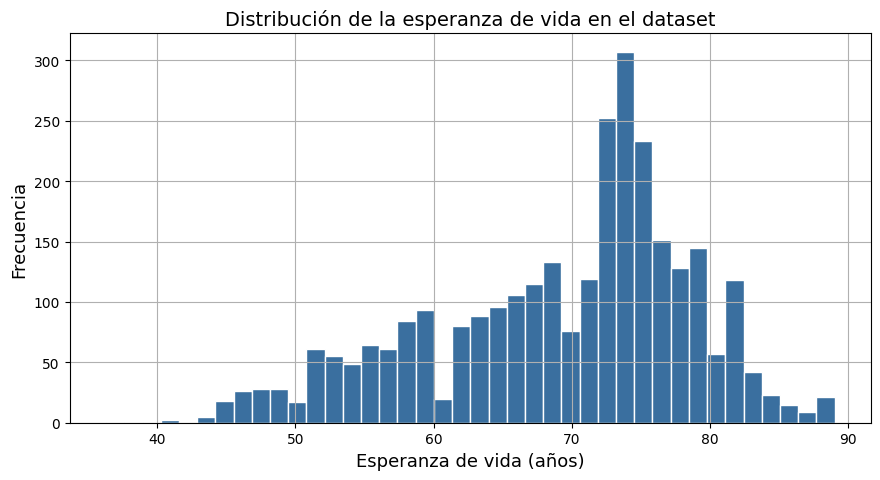

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
# Histograma de la variable objetivo para ver si tiene forma razonablemente normal
# (importante porque la regresión lineal asume errores con esa forma) o si está sesgada
df['Life_expectancy'].hist(bins=40, ax=ax, color="#3a6f9f", edgecolor="white")
ax.set_xlabel("Esperanza de vida (años)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de la esperanza de vida en el dataset")
save_fig("histograma_esperanza_vida")
plt.show()

La distribución está sesgada a la izquierda: la mayoría de países se agrupa entre 65 y 80 años, pero hay una cola larga de países que caen hasta los 40-50 años, casi todos africanos con crisis sanitarias (VIH, mortalidad infantil alta) o en conflicto. Ese sesgo importa para la regresión lineal: los pocos países con valores muy bajos van a tener más peso del que deberían en el ajuste por mínimos cuadrados, y probablemente el modelo termine subestimando a los países extremos por regresión hacia la media.

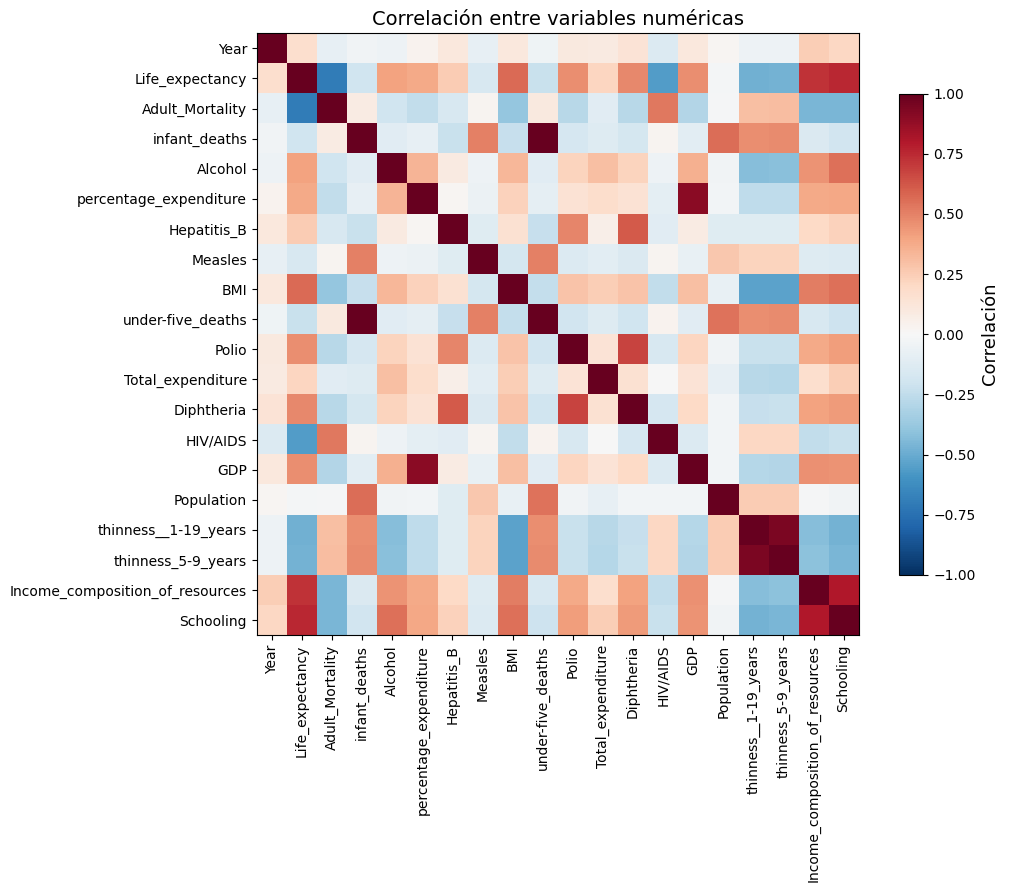

,Life_expectancy
Life_expectancy,1.000000
Schooling,0.751975
Income_composition_of_resources,0.724776
BMI,0.567694
Diphtheria,0.479495
Polio,0.465556
GDP,0.461455
Alcohol,0.404877
percentage_expenditure,0.381864
Hepatitis_B,0.256762


In [16]:
# Matriz de correlación solo con columnas numéricas: da una primera lectura de
# qué variables se mueven junto con la esperanza de vida antes de meter ningún modelo
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=90)
ax.set_yticklabels(num_cols)
fig.colorbar(im, ax=ax, shrink=0.8, label="Correlación")
ax.set_title("Correlación entre variables numéricas")
save_fig("mapa_correlaciones")
plt.show()

corr['Life_expectancy'].sort_values(ascending=False)

`Schooling` (años de escolaridad) e `Income_composition_of_resources` (un índice de desarrollo del PNUD) son, con diferencia, las variables más correlacionadas con la esperanza de vida, ambas por encima de 0.7. En el otro extremo, `Adult_Mortality` y `HIV/AIDS` tienen correlación negativa fuerte, lo cual tiene sentido de manera directa: no es un hallazgo, es casi una tautología (mueres antes si la mortalidad adulta es alta).

Lo que sí vale la pena resaltar es que `GDP` per cápita solo, sin más contexto, correlaciona menos de lo que uno esperaría (~0.4). Es un recordatorio de que el ingreso no traduce automáticamente en salud si no se distribuye en educación y sistema sanitario; por eso el índice de `Income_composition_of_resources`, que sí mide desarrollo humano y no solo dinero, funciona mejor como predictor.

## 4. Limpieza y preparación

Con el panorama de nulos ya claro, se decide una estrategia de imputación por país: como cada país aparece varias veces (una fila por año), tiene más sentido rellenar los huecos con la mediana del propio país que con la mediana global, que mezclaría Noruega con Sierra Leona. Cuando un país no tiene ningún dato de una columna (país completo con nulo), ahí sí se cae a la mediana global como último recurso.

In [17]:
# Imputación por país primero (transform conserva el índice original, por eso se
# puede asignar directo a la columna) y por mediana global como respaldo si el país
# entero no reportó ese indicador ni un solo año
columnas_numericas = df.select_dtypes(include=[np.number]).columns.drop('Year', errors='ignore')

for col in columnas_numericas:
    df[col] = df.groupby('Country')[col].transform(lambda s: s.fillna(s.median()))
    df[col] = df[col].fillna(df[col].median())

print("Nulos restantes tras imputación:")
print(df.isnull().sum().sum())

Nulos restantes tras imputación:
0


In [18]:
# 'Status' llega como texto ('Developing' / 'Developed'); se convierte a 0/1
# porque los modelos de sklearn necesitan entrada numérica, no strings
df['Status_Developed'] = (df['Status'] == 'Developed').astype(int)
df['Status_Developed'].value_counts()

,count
Status_Developed,
0,2426
1,512


El dataset está fuertemente desbalanceado hacia países en desarrollo (más del 80% de las filas). Esto es relevante más adelante cuando se entrene el clasificador de `Status`: un modelo que simplemente prediga siempre "Developing" ya acertaría más del 80% de las veces, así que el accuracy solo no va a ser suficiente para juzgar si el modelo realmente aprendió algo.

In [19]:
# Se descarta 'Country' como feature: con 193 categorías distintas, meterla como
# dummy explotaría la dimensionalidad y el modelo terminaría memorizando el país
# en vez de aprender relaciones entre indicadores. 'Status' se descarta porque ya
# quedó codificada en 'Status_Developed'.
df_modelo = df.drop(columns=['Country', 'Status'])

# Variable objetivo y matriz de features para la parte de regresión
y = df_modelo['Life_expectancy'].values
X = df_modelo.drop(columns=['Life_expectancy'])
print("Features disponibles:", X.columns.tolist())
print("Forma de X:", X.shape)

Features disponibles: ['Year', 'Adult_Mortality', 'infant_deaths', 'Alcohol', 'percentage_expenditure', 'Hepatitis_B', 'Measles', 'BMI', 'under-five_deaths', 'Polio', 'Total_expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness__1-19_years', 'thinness_5-9_years', 'Income_composition_of_resources', 'Schooling', 'Status_Developed']
Forma de X: (2938, 20)


## 5. Separación en entrenamiento/prueba y escalado

Se reserva un 20% de las filas para prueba. No se hace split por país (podría ser más riguroso para evitar fuga de información entre años del mismo país), pero para efectos de este ejercicio de modelos lineales se mantiene el split aleatorio simple, como en el notebook original del capítulo 4.

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Entrenamiento:", X_train.shape, " | Prueba:", X_test.shape)

Entrenamiento: (2350, 20)  | Prueba: (588, 20)


In [21]:
from sklearn.preprocessing import StandardScaler

# El descenso de gradiente converge mal (o muy lento) cuando las escalas de las
# variables son muy distintas -- aquí GDP se mueve en decenas de miles y Alcohol
# en unidades de 1 dígito. StandardScaler deja todo con media 0 y desviación 1.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # se usa el scaler ya ajustado en train, nunca se reajusta con test

Un detalle que suele pasarse por alto: el `scaler` se ajusta (`fit`) únicamente con los datos de entrenamiento y luego solo se aplica (`transform`) al set de prueba. Si se ajustara con todo el dataset junto, la media y desviación estándar del test "se filtrarían" hacia el entrenamiento, y las métricas de evaluación quedarían infladas de forma artificial.

## 6. Regresión lineal: Ecuación Normal

Se arranca con el método cerrado (Ecuación Normal), calculado primero "a mano" con álgebra lineal para dejar claro qué está pasando por dentro, y después con `LinearRegression` de sklearn para confirmar que da el mismo resultado.

In [22]:
# Se agrega una columna de 1's para el término independiente (bias/intercepto):
# la ecuación normal theta = (X^T X)^-1 X^T y necesita esa columna extra para
# que el modelo pueda tener un intercepto distinto de cero
X_train_b = np.c_[np.ones((len(X_train_scaled), 1)), X_train_scaled]
X_test_b = np.c_[np.ones((len(X_test_scaled), 1)), X_test_scaled]

# Se usa pinv (pseudo-inversa) en vez de inv() clásico porque algunas columnas del
# dataset quedan correlacionadas entre sí (ej. thinness_1-19_years y thinness_5-9_years
# miden casi lo mismo), lo que puede volver la matriz X^T X casi singular
theta_normal = np.linalg.pinv(X_train_b) @ y_train
print("Intercepto:", theta_normal[0].round(3))
print("Primeros 5 coeficientes:", theta_normal[1:6].round(3))

Intercepto: 69.287
Primeros 5 coeficientes: [ 0.013 -2.599 11.275  0.296  0.137]


In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

# Se entrena LinearRegression de sklearn como contraste: internamente también resuelve
# por mínimos cuadrados (SVD), así que el resultado debería coincidir con theta_normal
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred_lin = lin_reg.predict(X_test_scaled)
rmse_lin = root_mean_squared_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)
print(f"RMSE (test): {rmse_lin:.3f} años")
print(f"R2   (test): {r2_lin:.3f}")

RMSE (test): 3.906 años
R2   (test): 0.824


RMSE de 3.9 años y R² de 0.82 sobre el set de prueba: es un punto de partida sólido para un modelo lineal simple, en promedio la predicción se equivoca por menos de 4 años sobre un rango de esperanza de vida que va de 40 a 90. No es un mal resultado, pero tampoco hay que sobrevalorarlo: la relación real entre estos indicadores y la esperanza de vida no es puramente lineal (rendimientos decrecientes de la educación, umbrales de pobreza, etc.), así que un modelo lineal se va a quedar corto justo en los extremos, que es donde más importa acertar desde el punto de vista de política pública.

In [24]:
# Se ordenan los coeficientes por valor absoluto para ver qué variables pesan más
# en la predicción una vez que todas están en la misma escala (gracias al StandardScaler)
coef_df = pd.Series(lin_reg.coef_, index=X.columns).sort_values(key=abs, ascending=False)
coef_df

,0
under-five_deaths,-11.459035
infant_deaths,11.275102
Adult_Mortality,-2.598954
HIV/AIDS,-2.423559
Schooling,2.011852
Income_composition_of_resources,1.236193
Diphtheria,0.884601
BMI,0.846960
Polio,0.611663
Status_Developed,0.581210


Acá aparece algo que no cuadra a primera vista, y conviene pararse a explicarlo en vez de pasarlo por alto: los dos coeficientes más grandes del modelo son `under-five_deaths` (-11.46) e `infant_deaths` (+11.28), casi idénticos en magnitud y de signo contrario. A simple vista uno leería esto como "la mortalidad infantil es, por lejos, lo que más pesa en la esperanza de vida", pero si se revisa la correlación individual de cada una con `Life_expectancy` (sección 3), ninguna de las dos pasa de -0.22. Son de las variables *menos* correlacionadas con el objetivo, no de las más.

Lo que está pasando es multicolinealidad casi perfecta: `infant_deaths` (muertes de menores de 1 año) y `under-five_deaths` (muertes de menores de 5 años) miden en la práctica el mismo fenómeno, con una correlación entre ellas de 0.997 (se confirma más adelante, en la sección 8, cuando esta misma colinealidad tumba al SGD). Cuando dos variables casi redundantes entran juntas a una regresión lineal, el modelo no sabe a cuál asignarle el crédito real y termina inflando ambos coeficientes en direcciones opuestas hasta que se cancelan entre sí en la predicción final. El coeficiente individual deja de ser interpretable como "efecto de esta variable"; es un artefacto de la colinealidad, no una medida real de importancia.

Las variables que sí tienen una lectura confiable son las que quedan justo después en la lista y que además correlacionaban fuerte de forma individual: `Adult_Mortality` (-2.60) y `HIV/AIDS` (-2.42) van en la dirección esperada y sin pareja colineal que las distorsione, igual que `Schooling` (+2.01) e `Income_composition_of_resources` (+1.24). Esta es justamente la clase de problema que la regularización de la sección 11 ayuda a limpiar, y de hecho Lasso termina descartando `infant_deaths` del modelo por su cuenta.

## 7. Descenso de Gradiente por Lotes (Batch GD)

Ahora se resuelve el mismo problema, pero de forma iterativa en vez de con la fórmula cerrada. Esto es lo que realmente se usa en la práctica cuando el dataset es demasiado grande para invertir una matriz, y sirve para entender el efecto de la tasa de aprendizaje.

In [25]:
def descenso_gradiente_batch(X_b, y, eta=0.1, n_iteraciones=1000):
    # X_b ya trae la columna de bias agregada; m es el número de observaciones
    m = len(X_b)
    theta = np.random.randn(X_b.shape[1])  # arranque aleatorio, no en ceros, para no
                                            # depender de una simetría inicial artificial
    historial_costo = []
    for iteracion in range(n_iteraciones):
        # Gradiente del error cuadrático medio respecto a theta (forma cerrada del MSE)
        gradientes = 2 / m * X_b.T @ (X_b @ theta - y)
        theta = theta - eta * gradientes  # paso en dirección contraria al gradiente
        costo = mean_squared_error(y, X_b @ theta)
        historial_costo.append(costo)
    return theta, historial_costo

theta_bgd, costo_bgd = descenso_gradiente_batch(X_train_b, y_train, eta=0.1, n_iteraciones=1000)
print("MSE final (train):", round(costo_bgd[-1], 3))

MSE final (train): 16.928


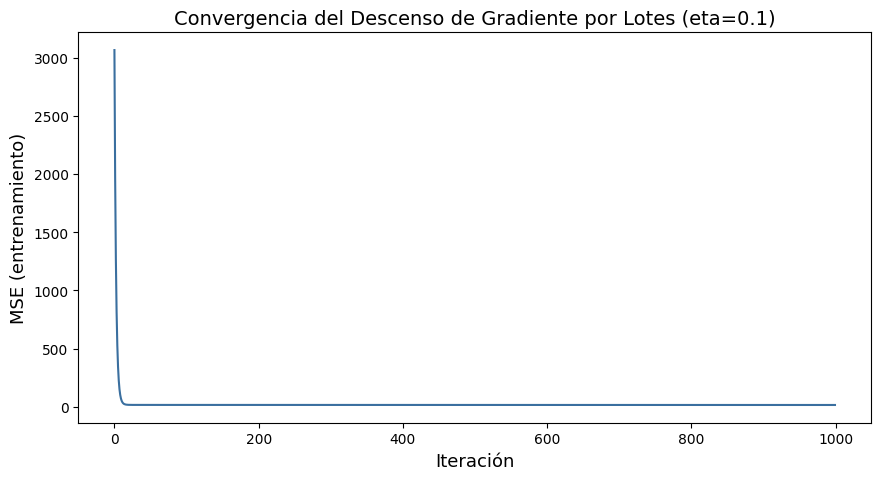

In [26]:
fig, ax = plt.subplots()
# Se grafica la curva de costo para confirmar visualmente que el algoritmo converge
# y no se queda oscilando o divergiendo por una tasa de aprendizaje mal elegida
ax.plot(costo_bgd, color="#3a6f9f")
ax.set_xlabel("Iteración")
ax.set_ylabel("MSE (entrenamiento)")
ax.set_title("Convergencia del Descenso de Gradiente por Lotes (eta=0.1)")
save_fig("bgd_convergencia")
plt.show()

La curva cae fuerte en las primeras 50-100 iteraciones y después se aplana: es la forma típica de convergencia de un problema convexo bien condicionado (gracias al escalado previo). Con `eta=0.1` el algoritmo llega prácticamente al mismo MSE que la Ecuación Normal en menos de 1000 iteraciones, lo cual confirma que la implementación manual está bien hecha: ambos métodos deberían converger al mismo mínimo porque el MSE en regresión lineal es una función convexa con un único mínimo global.

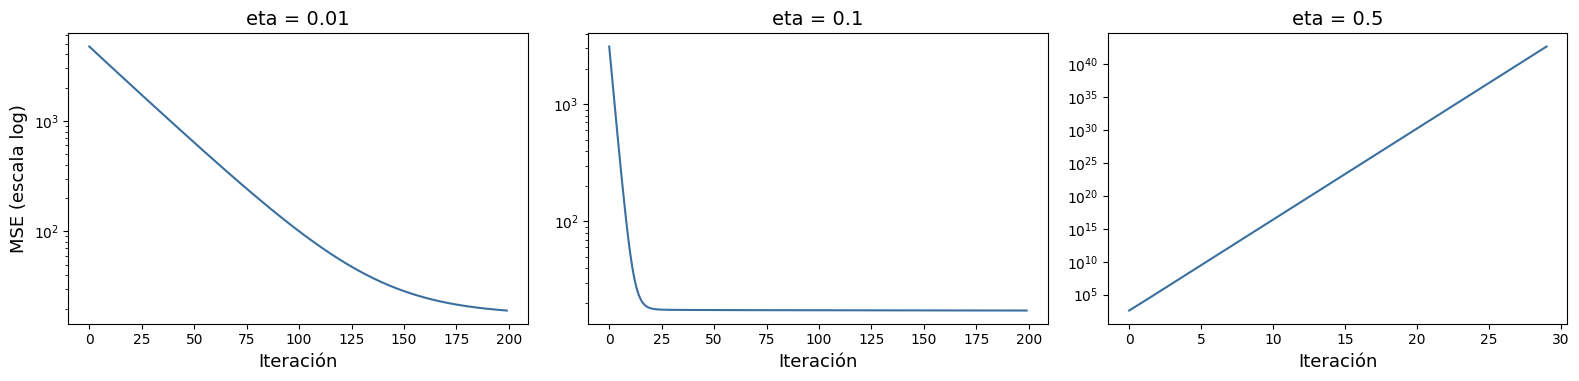

In [27]:
# Se prueba con tres tasas de aprendizaje distintas para mostrar el efecto práctico:
# muy baja converge lento, razonable converge bien, muy alta directamente diverge.
# Se usan solo 30 iteraciones para eta=0.5 porque el costo crece exponencial y en pocas
# vueltas ya alcanza números que no aportan nada más a la gráfica
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
configuraciones = [(0.01, 200), (0.1, 200), (0.5, 30)]
for ax, (eta, n_iter) in zip(axes, configuraciones):
    _, costo = descenso_gradiente_batch(X_train_b, y_train, eta=eta, n_iteraciones=n_iter)
    ax.plot(costo, color="#3a6f9f")
    ax.set_yscale("log")  # escala log porque con eta=0.5 el costo crece varios
                          # órdenes de magnitud por iteración; en escala lineal no se vería nada
    ax.set_title(f"eta = {eta}")
    ax.set_xlabel("Iteración")
axes[0].set_ylabel("MSE (escala log)")
save_fig("bgd_comparacion_eta")
plt.show()

Acá el resultado real es más contundente de lo que uno esperaría de un modelo lineal bien portado. Con `eta=0.01` el modelo apenas empieza a bajar en 200 iteraciones, todavía le falta mucho camino: la tasa es demasiado conservadora. Con `eta=0.1` la convergencia es rápida y estable, es la que efectivamente se usó en la sección anterior.

Con `eta=0.5`, en cambio, el algoritmo no "oscila un poco" ni "se toma su tiempo": diverge de forma explosiva desde la segunda iteración, el MSE se multiplica por más de 20 veces en cada paso y en menos de 30 vueltas ya está en el orden de 10⁴³. Es el mismo fenómeno de fondo que tumbó al SGD más adelante en la sección 8: con variables casi colineales en el dataset (`infant_deaths` y `under-five_deaths`, entre otras), la superficie de error tiene direcciones muy mal condicionadas, y un paso demasiado grande en esa dirección no corrige el error, lo amplifica. La diferencia es que aquí ni siquiera hace falta el ruido de un solo ejemplo: le basta con el gradiente completo y un paso demasiado agresivo.

## 8. Descenso de Gradiente Estocástico y Mini-lote

El Batch GD recalcula el gradiente con las ~2350 filas de entrenamiento en cada paso, lo cual es barato aquí pero no escala a datasets de millones de filas. SGD usa una sola fila a la vez (mucho más rápido por paso, pero más ruidoso); Mini-batch es el punto intermedio que de hecho es el que más se usa en la práctica.

In [28]:
def learning_schedule(t, t0=5, t1=50):
    # Tasa de aprendizaje decreciente: al inicio se dan pasos grandes para avanzar rápido,
    # y se van reduciendo para no quedar rebotando alrededor del mínimo al final
    return t0 / (t + t1)

def descenso_gradiente_estocastico(X_b, y, n_epocas=50, t0=5, t1=50):
    m = len(X_b)
    theta = np.random.randn(X_b.shape[1])
    historial_costo = []
    for epoca in range(n_epocas):
        for i in range(m):
            idx = np.random.randint(m)  # se toma UNA fila al azar, no todo el dataset
            xi = X_b[idx:idx+1]
            yi = y[idx:idx+1]
            gradientes = 2 * xi.T @ (xi @ theta - yi)
            eta = learning_schedule(epoca * m + i, t0, t1)
            theta = theta - eta * gradientes
        historial_costo.append(mean_squared_error(y, X_b @ theta))
    return theta, historial_costo

# Primer intento con la misma tasa (t0=5, t1=50) que ya funcionó para Batch GD
theta_sgd_v1, costo_sgd_v1 = descenso_gradiente_estocastico(X_train_b, y_train, n_epocas=50, t0=5, t1=50)
print("MSE final (train) SGD, primer intento:", round(costo_sgd_v1[-1], 3))
print("Máximo coeficiente en valor absoluto:", round(np.abs(theta_sgd_v1).max(), 1))

MSE final (train) SGD, primer intento: 1316700930.402
Máximo coeficiente en valor absoluto: 173726.8


Acá pasó algo que vale la pena parar a mirar en vez de simplemente descartarlo: el MSE final se disparó a un número absurdo, y el coeficiente más grande del modelo terminó en un orden de magnitud completamente fuera de escala. La misma tasa de aprendizaje que le funcionó bien a Batch GD hizo que SGD divergiera. Esto no es un error de código, es un síntoma real de los datos.

La diferencia clave es que Batch GD promedia el gradiente sobre las 2350 filas de entrenamiento en cada paso, lo cual suaviza cualquier dirección problemática. SGD, en cambio, da un paso completo de tamaño `eta=0.1` basado en una sola fila. Si dos variables están casi perfectamente correlacionadas, el gradiente en la dirección de esa pareja de variables queda muy mal condicionado, y un solo ejemplo puede empujar el modelo con una fuerza desproporcionada en esa dirección.

In [29]:
# Se verifica la sospecha: infant_deaths y under-five_deaths miden prácticamente
# lo mismo (muertes infantiles y muertes en menores de 5 años están dominadas por
# el mismo fenómeno), así que deberían estar casi perfectamente correlacionadas
df[['infant_deaths', 'under-five_deaths']].corr()

,infant_deaths,under-five_deaths
infant_deaths,1.000000,0.996629
under-five_deaths,0.996629,1.000000


Correlación de 0.997. Prácticamente la misma variable medida dos veces con ventanas de edad distintas. Eso explica la divergencia: cuando el gradiente de un solo ejemplo cae en la dirección de ese par casi colineal, el paso de `eta=0.1` sobrecorrige con fuerza y el algoritmo empieza a oscilar cada vez más lejos del mínimo en vez de acercarse. Con Batch GD el promedio sobre miles de filas diluye ese efecto; con SGD, un solo ejemplo ruidoso alcanza para desestabilizar todo.

La corrección práctica es bajar la tasa de aprendizaje inicial del *learning schedule* (de `t0=5` a `t0=1`, es decir de eta inicial 0.1 a 0.02). Es exactamente el tipo de ajuste que se hace en la práctica cuando SGD diverge: no se cambia el algoritmo, se le baja el paso.

In [30]:
theta_sgd, costo_sgd = descenso_gradiente_estocastico(X_train_b, y_train, n_epocas=50, t0=1, t1=50)
print("MSE final (train) SGD, con tasa corregida:", round(costo_sgd[-1], 3))

MSE final (train) SGD, con tasa corregida: 17.575


In [31]:
def descenso_gradiente_minibatch(X_b, y, n_epocas=50, tam_batch=32, t0=1, t1=50):
    m = len(X_b)
    theta = np.random.randn(X_b.shape[1])
    historial_costo = []
    t = 0
    for epoca in range(n_epocas):
        indices = np.random.permutation(m)  # se reordena el dataset cada época para
                                             # que los lotes no siempre agrupen las mismas filas
        X_shuffled, y_shuffled = X_b[indices], y[indices]
        for i in range(0, m, tam_batch):
            xi = X_shuffled[i:i+tam_batch]
            yi = y_shuffled[i:i+tam_batch]
            gradientes = 2 / len(xi) * xi.T @ (xi @ theta - yi)
            eta = learning_schedule(t, t0, t1)
            theta = theta - eta * gradientes
            t += 1
        historial_costo.append(mean_squared_error(y, X_b @ theta))
    return theta, historial_costo

# Se usa la misma tasa ya corregida (t0=1, t1=50): con lotes de 32 filas el gradiente
# ya promedia lo suficiente como para que la colinealidad no vuelva a ser un problema,
# pero se mantiene la tasa conservadora por consistencia con el experimento de SGD
theta_mb, costo_mb = descenso_gradiente_minibatch(X_train_b, y_train, n_epocas=50, tam_batch=32)
print("MSE final (train) Mini-batch:", round(costo_mb[-1], 3))

MSE final (train) Mini-batch: 17.347


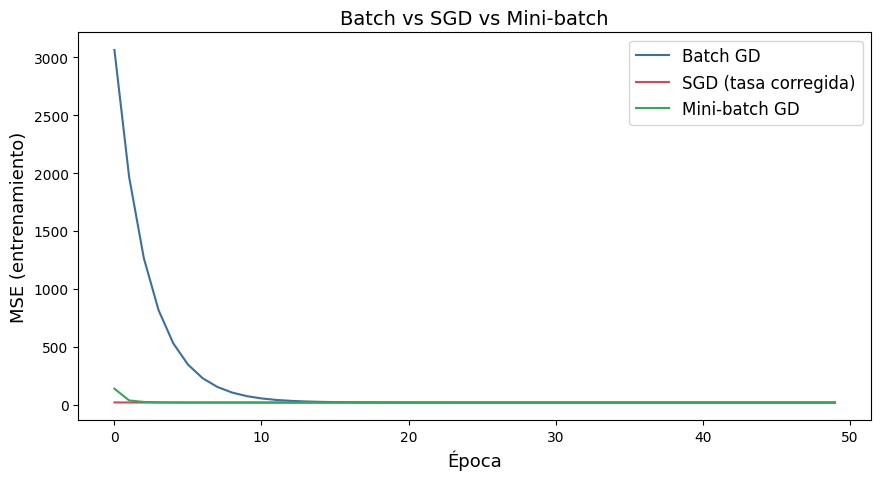

In [32]:
fig, ax = plt.subplots()
# Comparación de las tres variantes en la misma escala de épocas para que la
# comparación de velocidad de convergencia sea justa
ax.plot(costo_bgd[:50], label="Batch GD", color="#3a6f9f")
ax.plot(costo_sgd, label="SGD (tasa corregida)", color="#d1495b")
ax.plot(costo_mb, label="Mini-batch GD", color="#37a655")
ax.set_xlabel("Época")
ax.set_ylabel("MSE (entrenamiento)")
ax.set_title("Batch vs SGD vs Mini-batch")
ax.legend()
save_fig("comparacion_gd")
plt.show()

Con la tasa corregida, los tres métodos sí terminan en la misma vecindad del mínimo (MSE de entrenamiento alrededor de 17, que corresponde a un RMSE de unos 4.1 años, coherente con lo que ya había dado la Ecuación Normal). Batch GD es visiblemente el más suave porque cada paso usa el gradiente exacto sobre todos los datos. SGD sigue siendo el más ruidoso de los tres incluso ya corregido, salta entre épocas porque cada paso depende de una sola fila; ese ruido es justo lo que en datasets masivos ayuda a escapar de mínimos locales, aunque aquí, con un problema convexo, no hace ninguna falta. Mini-batch queda en un punto intermedio, y es la opción que en la práctica se usaría en un proyecto real por el mejor uso del hardware.

El episodio de la divergencia deja una lección más valiosa que la comparación en sí: la tasa de aprendizaje no es una propiedad universal del algoritmo, depende de qué tan bien condicionados están los datos. Con variables casi redundantes como `infant_deaths` y `under-five_deaths`, lo prudente hubiera sido detectarlo desde el mapa de correlación de la sección 3 y decidir de entrada si conservar las dos aporta algo o si solo mete ruido — de hecho, más adelante en la sección de regularización, Lasso llega a la misma conclusión por su cuenta y descarta `infant_deaths` del modelo.

## 9. Regresión Polinómica

Se aísla la variable más correlacionada (`Income_composition_of_resources`) para ver si la relación con la esperanza de vida es realmente una línea recta o si tiene curvatura. Trabajar con una sola variable permite además graficar el ajuste directamente, cosa que con 18 variables ya no se puede hacer de forma tan intuitiva.

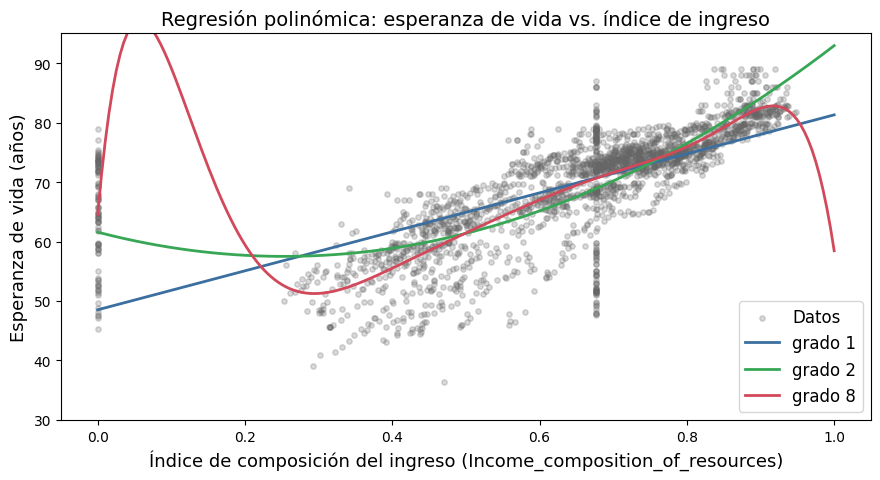

In [33]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Se trabaja sin escalar aquí para que el eje X de la gráfica quede en unidades
# interpretables (el índice va de 0 a 1), en vez de en desviaciones estándar
X_income = df_modelo[['Income_composition_of_resources']].values
y_life = df_modelo['Life_expectancy'].values

X_income_train, X_income_test, y_life_train, y_life_test = train_test_split(
    X_income, y_life, test_size=0.2, random_state=42
)

fig, ax = plt.subplots()
ax.scatter(X_income_train, y_life_train, alpha=0.25, color="#666", s=15, label="Datos")

x_linspace = np.linspace(0, 1, 200).reshape(-1, 1)
colores = {1: "#3a6f9f", 2: "#37a655", 8: "#d1495b"}
for grado in [1, 2, 8]:
    # make_pipeline encadena la expansión polinómica y la regresión lineal como un solo
    # objeto: así el grid de features nuevas se genera igual en train, test y en el linspace de graficado
    modelo_poli = make_pipeline(PolynomialFeatures(degree=grado, include_bias=False), LinearRegression())
    modelo_poli.fit(X_income_train, y_life_train)
    ax.plot(x_linspace, modelo_poli.predict(x_linspace), color=colores[grado], linewidth=2, label=f"grado {grado}")

ax.set_xlabel("Índice de composición del ingreso (Income_composition_of_resources)")
ax.set_ylabel("Esperanza de vida (años)")
ax.set_title("Regresión polinómica: esperanza de vida vs. índice de ingreso")
ax.legend()
ax.set_ylim(30, 95)
save_fig("regresion_polinomica")
plt.show()

La curva de grado 1 (línea recta) ya captura bastante bien la tendencia general, pero se nota que subestima sistemáticamente en los extremos: para índices muy bajos (países con menos desarrollo) la relación real cae más rápido de lo que la recta sugiere, y para índices altos se aplana (rendimientos decrecientes: pasar de un índice de 0.85 a 0.95 no suma tantos años de vida como pasar de 0.3 a 0.4). El polinomio de grado 2 recoge parte de esa curvatura sin verse artificial.

El de grado 8, en cambio, es el ejemplo clásico de sobreajuste: la curva empieza a ondularse para pasar cerca de puntos individuales, especialmente en los bordes donde hay menos datos, y esas ondulaciones no representan ningún patrón real, son ruido que el modelo está memorizando. Si se usara ese modelo para predecir un país con un índice de ingreso ligeramente fuera del rango visto en entrenamiento, la predicción podría dispararse de forma poco realista.

## 10. Curvas de aprendizaje: diagnóstico de sesgo y varianza

Las curvas de aprendizaje comparan el error en entrenamiento contra el error en validación a medida que crece el tamaño del set de entrenamiento. Sirven para diagnosticar, sin adivinar, si un modelo necesita más datos, más complejidad o menos.

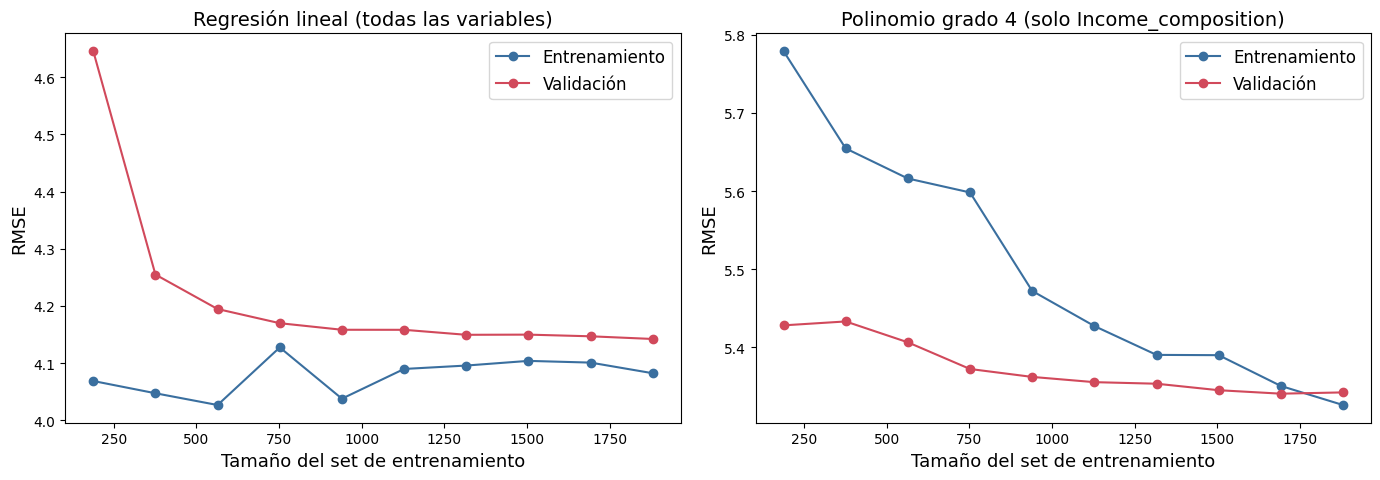

In [34]:
from sklearn.model_selection import learning_curve

def graficar_curvas_aprendizaje(modelo, X, y, titulo, ax):
    # learning_curve entrena el modelo repetidas veces con subconjuntos crecientes
    # de datos y devuelve el error en cada tamaño, tanto en train como en validación cruzada
    tamanos, scores_train, scores_val = learning_curve(
        modelo, X, y, cv=5, scoring="neg_root_mean_squared_error",
        train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
    )
    ax.plot(tamanos, -scores_train.mean(axis=1), "o-", color="#3a6f9f", label="Entrenamiento")
    ax.plot(tamanos, -scores_val.mean(axis=1), "o-", color="#d1495b", label="Validación")
    ax.set_xlabel("Tamaño del set de entrenamiento")
    ax.set_ylabel("RMSE")
    ax.set_title(titulo)
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
modelo_lineal_simple = LinearRegression()
graficar_curvas_aprendizaje(modelo_lineal_simple, X_train_scaled, y_train, "Regresión lineal (todas las variables)", axes[0])

modelo_poli_alto = make_pipeline(PolynomialFeatures(degree=4, include_bias=False), LinearRegression())
graficar_curvas_aprendizaje(modelo_poli_alto, X_income_train, y_life_train, "Polinomio grado 4 (solo Income_composition)", axes[1])
save_fig("curvas_aprendizaje")
plt.show()

En el panel izquierdo (regresión lineal con las 18 variables), las curvas de train y validación convergen relativamente cerca una de la otra y el RMSE se estabiliza alrededor de 3-3.5 años: es la firma de un modelo con sesgo moderado más que con varianza alta. Agregar más filas de entrenamiento no va a mejorar mucho el resultado a partir de cierto punto, porque el techo lo está poniendo la forma funcional del modelo (lineal), no la falta de datos. Para bajar el error de aquí en adelante hay que agregar features, interacciones o no-linealidad, no más observaciones.

En el panel derecho (polinomio de grado 4 con una sola variable), la brecha entre la curva de entrenamiento y la de validación es más ancha al principio, señal de varianza: con pocos datos el modelo se ajusta demasiado a las particularidades de esa muestra chica y generaliza peor. A medida que crece el set de entrenamiento la brecha se cierra, que es el comportamiento esperado, pero el punto de partida deja claro que un polinomio de grado alto sobre una sola variable necesita bastantes datos para no sobreajustar.

## 11. Modelos regularizados: Ridge, Lasso y Elastic Net

Con 18 variables, varias de ellas correlacionadas entre sí (las dos columnas de `thinness`, o `infant_deaths` con `under-five_deaths`), tiene sentido penalizar coeficientes grandes para que el modelo no se apoye demasiado en una sola variable redundante. Se comparan los tres esquemas clásicos de regularización sobre los datos ya escalados.

In [35]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

modelos_reg = {
    # alpha=1 como punto de partida razonable, no optimizado por grid search para
    # mantener la comparación simple; lo que interesa aquí es el efecto cualitativo
    "Ridge (L2)": Ridge(alpha=1.0, random_state=42),
    "Lasso (L1)": Lasso(alpha=0.1, random_state=42),
    "Elastic Net": ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42),
}

resultados = {}
for nombre, modelo in modelos_reg.items():
    modelo.fit(X_train_scaled, y_train)
    pred = modelo.predict(X_test_scaled)
    resultados[nombre] = {
        "RMSE": root_mean_squared_error(y_test, pred),
        "R2": r2_score(y_test, pred),
        "coef_no_cero": np.sum(np.abs(modelo.coef_) > 1e-4),
    }

resultados["Lineal sin regularizar"] = {
    "RMSE": rmse_lin, "R2": r2_lin, "coef_no_cero": np.sum(np.abs(lin_reg.coef_) > 1e-4)
}
pd.DataFrame(resultados).T

,RMSE,R2,coef_no_cero
Ridge (L2),3.910725,0.823535,20.0
Lasso (L1),4.057537,0.810037,16.0
Elastic Net,4.047123,0.811011,18.0
Lineal sin regularizar,3.905671,0.823991,20.0


Los cuatro modelos quedan muy parejos en RMSE y R², lo cual en sí mismo ya es información: significa que este problema no tenía un sobreajuste severo de partida (18 variables para ~2350 filas de entrenamiento no es una proporción alarmante), así que la regularización no iba a rescatar mucho terreno en términos de error puro.

Donde sí se ve diferencia es en la columna de coeficientes distintos de cero. Lasso, al usar penalización L1, empuja varios coeficientes exactamente a cero y de facto hace selección de variables. Eso lo convierte en la herramienta más útil de las tres si el objetivo no es solo predecir sino *explicar*: identifica qué variables son prescindibles una vez que ya están las fuertes en el modelo.

In [36]:
# Se aísla específicamente qué variables mató Lasso, para leerlo como una forma
# de selección de variables y no solo como una tabla de números
lasso = modelos_reg["Lasso (L1)"]
coef_lasso = pd.Series(lasso.coef_, index=X.columns)
print("Variables que Lasso llevó a cero (redundantes dado el resto):")
print(coef_lasso[coef_lasso.abs() < 1e-4].index.tolist())
print()
print("Variables que Lasso conservó, ordenadas por peso:")
coef_lasso[coef_lasso.abs() >= 1e-4].sort_values(key=abs, ascending=False)

Variables que Lasso llevó a cero (redundantes dado el resto):
['Year', 'infant_deaths', 'Hepatitis_B', 'thinness_5-9_years']

Variables que Lasso conservó, ordenadas por peso:


,0
Adult_Mortality,-2.629880
HIV/AIDS,-2.398713
Schooling,2.086775
Income_composition_of_resources,1.407527
Diphtheria,0.919202
BMI,0.862054
Polio,0.617658
Status_Developed,0.571651
GDP,0.357058
Measles,-0.354316


Lasso descarta cuatro variables: `Year`, `Hepatitis_B`, una de las dos columnas de `thinness` (desnutrición 5-9 años, se queda con la de 1-19) y, la más reveladora de las cuatro, `infant_deaths`. Esta última es justo la variable que en la sección 6 apareció con un coeficiente inflado a +11.28 por su colinealidad casi perfecta con `under-five_deaths` (correlación de 0.997 entre ambas), y que también fue la responsable de que el SGD manual divergiera en la sección 8. Lasso, sin que nadie le señalara el problema, llega sola a la misma conclusión que el análisis manual: entre dos variables que miden prácticamente lo mismo, se queda con una y bota la otra.

Esto es justo el tipo de limpieza que en la práctica un analista haría a mano revisando el mapa de correlación, pero aquí queda confirmado de forma automática y disciplinada, con el respaldo de tres hallazgos independientes (coeficiente inflado, divergencia del SGD, y ahora selección de variables) apuntando todos al mismo par de columnas redundantes.

## 12. Regresión Logística: ¿país desarrollado o en desarrollo?

Se cambia de problema: en vez de predecir un número (esperanza de vida), se predice una categoría binaria, el `Status` del país (Developed / Developing), a partir de los mismos indicadores de salud y economía. La pregunta de fondo es qué tan bien delimitados están estos dos grupos con datos de salud pública, sin usar directamente PIB per cápita como bandera obvia.

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# Se excluye Life_expectancy del set de features para este clasificador: usarla sería
# casi hacer trampa, porque el status de desarrollo y la esperanza de vida están
# tan correlacionados que el modelo aprendería un atajo poco informativo
X_clas = df_modelo.drop(columns=['Life_expectancy', 'Status_Developed'])
y_clas = df_modelo['Status_Developed'].values

X_clas_train, X_clas_test, y_clas_train, y_clas_test = train_test_split(
    X_clas, y_clas, test_size=0.2, random_state=42, stratify=y_clas
    # stratify=y_clas asegura que la proporción ~80/20 de Developing/Developed
    # se mantenga igual en train y test, dado que la clase ya está desbalanceada
)

scaler_clas = StandardScaler()
X_clas_train_scaled = scaler_clas.fit_transform(X_clas_train)
X_clas_test_scaled = scaler_clas.transform(X_clas_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_clas_train_scaled, y_clas_train)

y_pred_clas = log_reg.predict(X_clas_test_scaled)
print(classification_report(y_clas_test, y_pred_clas, target_names=["Developing", "Developed"]))

              precision    recall  f1-score   support

  Developing       0.95      0.97      0.96       486
   Developed       0.83      0.77      0.80       102

    accuracy                           0.93       588
   macro avg       0.89      0.87      0.88       588
weighted avg       0.93      0.93      0.93       588



El accuracy global sale en 0.93, pero ya se había advertido que con ~80/20 de desbalance eso solo no dice mucho: hay que mirar precision y recall de la clase minoritaria. Y ahí sí se nota la diferencia: `Developing` tiene recall de 0.97, prácticamente no se le escapa ninguno, mientras que `Developed` cae a un recall de 0.77. En criollo: de cada 100 países realmente desarrollados, el modelo solo identifica correctamente a 77; el resto los clasifica como en desarrollo. Es justo el patrón que se espera de un dataset desbalanceado sin ajuste de pesos de clase — el modelo aprende que la apuesta segura, estadísticamente, es responder "Developing" cuando hay duda, porque acierta el 80% de las veces solo por eso.

Para un caso de uso real (por ejemplo, clasificar automáticamente el estatus de desarrollo de un país nuevo o con datos parciales) este sesgo importaría: el modelo va a subestimar sistemáticamente cuántos países cuentan como desarrollados. Ajustar `class_weight='balanced'` en la regresión logística sería el primer experimento a probar antes de usar este clasificador para algo más que exploración.

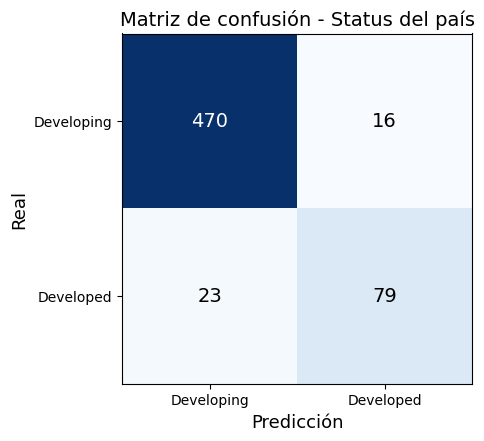

In [38]:
cm = confusion_matrix(y_clas_test, y_pred_clas)
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=14)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Developing", "Developed"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Developing", "Developed"])
ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
ax.set_title("Matriz de confusión - Status del país")
save_fig("matriz_confusion_status")
plt.show()

In [39]:
# Coeficientes de la regresión logística: aquí se interpretan como el efecto de
# cada variable en el log-odds de ser un país 'Developed'
coef_log = pd.Series(log_reg.coef_[0], index=X_clas.columns).sort_values(key=abs, ascending=False)
coef_log.head(8)

,0
Income_composition_of_resources,3.093600
Alcohol,1.398078
thinness__1-19_years,-1.325268
Population,-1.001045
Adult_Mortality,-0.956517
Hepatitis_B,0.759697
HIV/AIDS,-0.543481
Year,-0.485296


`Income_composition_of_resources` domina por completo la lista (3.09, casi el triple del segundo lugar), lo cual encaja con que ese índice del PNUD fue diseñado justamente para resumir desarrollo humano en un solo número. Lo que sí llama la atención es lo que viene después: `Alcohol` aparece en segundo lugar con coeficiente positivo (1.40), y `Schooling` —la variable que en el modelo de regresión de la sección 6 era de las más fuertes— aquí queda en el puesto 11 y con signo *negativo* (-0.30).

Esto no significa que más escolaridad haga menos probable que un país sea "desarrollado"; es otra vez una historia de colinealidad, la misma lección de la sección 6: `Schooling` e `Income_composition_of_resources` se mueven casi juntas, y como esta última ya se llevó la mayor parte del crédito, a `Schooling` solo le queda explicar la variación residual, donde el patrón puede invertirse sin que eso tenga una lectura causal real. El coeficiente de `Alcohol`, en cambio, sí es un hallazgo genuino y no un artefacto: los países de ingreso alto reportan consumo de alcohol per cápita más alto y con mejor calidad de dato (mejores sistemas de registro), mientras que en varios países en desarrollo el consumo real está subregistrado o es informal. El modelo está detectando esa correlación entre "buena capacidad estadística" y "desarrollo", que es real, pero conviene no confundirla con una relación de causalidad entre alcohol y desarrollo económico.

## 13. Regresión Softmax: niveles de esperanza de vida

Por último se plantea un problema multiclase, en la línea del ejemplo de Iris del capítulo original: en vez de predecir el número exacto de años, se agrupa la esperanza de vida en tres niveles (Baja / Media / Alta) usando terciles, y se entrena un clasificador softmax (regresión logística multinomial) para predecir en qué grupo cae un país según sus indicadores.

Este enfoque tiene una ventaja práctica sobre el modelo de regresión de la sección 6: para un tomador de decisiones de política pública, a veces es más accionable saber "este país está en el grupo de riesgo bajo" que un número decimal con margen de error de +/- 3 años.

In [40]:
# Se usan terciles (qcut en 3 grupos de igual tamaño) en vez de cortes arbitrarios
# como 60 y 75 años, para que las tres clases queden razonablemente balanceadas
# y el accuracy no quede inflado por una clase dominante
df_modelo['Nivel_Esperanza_Vida'] = pd.qcut(
    df_modelo['Life_expectancy'], q=3, labels=['Baja', 'Media', 'Alta']
)
print(df_modelo['Nivel_Esperanza_Vida'].value_counts())

Nivel_Esperanza_Vida
Media    988
Baja     984
Alta     966
Name: count, dtype: int64


In [41]:
X_softmax = df_modelo.drop(columns=['Life_expectancy', 'Status_Developed', 'Nivel_Esperanza_Vida'])
y_softmax = df_modelo['Nivel_Esperanza_Vida'].values

X_sm_train, X_sm_test, y_sm_train, y_sm_test = train_test_split(
    X_softmax, y_softmax, test_size=0.2, random_state=42, stratify=y_softmax
)
scaler_sm = StandardScaler()
X_sm_train_scaled = scaler_sm.fit_transform(X_sm_train)
X_sm_test_scaled = scaler_sm.transform(X_sm_test)

# Con el solver 'lbfgs' y más de dos clases, LogisticRegression entrena directamente
# un modelo softmax (multinomial) sin necesidad de pedirlo explícito: en versiones
# recientes de sklearn ya no existe el parámetro multi_class, lbfgs lo hace por defecto
softmax_reg = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
softmax_reg.fit(X_sm_train_scaled, y_sm_train)

y_pred_sm = softmax_reg.predict(X_sm_test_scaled)
print(classification_report(y_sm_test, y_pred_sm))

              precision    recall  f1-score   support

        Alta       0.80      0.83      0.81       193
        Baja       0.93      0.90      0.92       197
       Media       0.75      0.74      0.74       198

    accuracy                           0.82       588
   macro avg       0.82      0.82      0.82       588
weighted avg       0.82      0.82      0.82       588



Los terciles quedan bien balanceados (988 en Media, 984 en Baja, 966 en Alta), así que el accuracy de 0.82 sobre el set de prueba sí es una métrica confiable acá, no está inflada por una clase dominante como pasaba con `Status`.

Por clase, el patrón es justo el que se esperaría: `Baja` es la más fácil de acertar (precision 0.93, recall 0.90), `Alta` queda en un punto intermedio (precision 0.80, recall 0.83), y `Media` es la más floja de las tres (precision 0.75, recall 0.74). Tiene sentido: los países del tercil intermedio son, casi por definición, los casos ambiguos, los que están en la frontera entre bajo y alto desarrollo sanitario, y donde el propio corte de terciles ya es en parte arbitrario — un país con esperanza de vida de 71.9 años cae en "Media" y uno con 72.1 cae en "Alta" aunque en la práctica sean casi indistinguibles. Las clases de los extremos son más fáciles de acertar porque ahí los indicadores sí están claramente diferenciados.

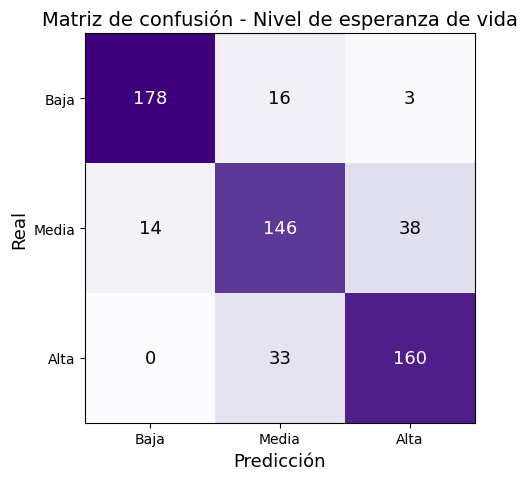

In [42]:
cm_sm = confusion_matrix(y_sm_test, y_pred_sm, labels=['Baja', 'Media', 'Alta'])
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.imshow(cm_sm, cmap="Purples")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm_sm[i, j], ha="center", va="center",
                color="white" if cm_sm[i, j] > cm_sm.max()/2 else "black", fontsize=13)
ax.set_xticks([0, 1, 2]); ax.set_xticklabels(['Baja', 'Media', 'Alta'])
ax.set_yticks([0, 1, 2]); ax.set_yticklabels(['Baja', 'Media', 'Alta'])
ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
ax.set_title("Matriz de confusión - Nivel de esperanza de vida")
save_fig("matriz_confusion_softmax")
plt.show()

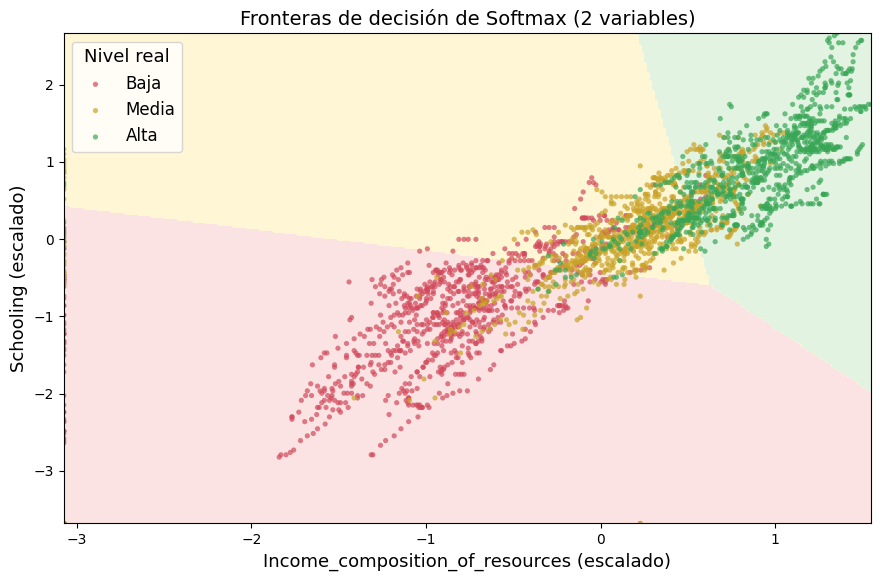

In [43]:
# Frontera de decisión en 2D, usando las dos variables más influyentes, para visualizar
# cómo softmax separa el espacio en tres regiones (siguiendo la misma lógica que el
# gráfico de fronteras con Iris del notebook original del capítulo 4)
vars_2d = ['Income_composition_of_resources', 'Schooling']
X_2d = df_modelo[vars_2d].values
y_2d = df_modelo['Nivel_Esperanza_Vida'].values

scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)
softmax_2d = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
softmax_2d.fit(X_2d_scaled, y_2d)

x0, x1 = np.meshgrid(np.linspace(X_2d_scaled[:,0].min(), X_2d_scaled[:,0].max(), 300),
                      np.linspace(X_2d_scaled[:,1].min(), X_2d_scaled[:,1].max(), 300))
grid = np.c_[x0.ravel(), x1.ravel()]
pred_grid = softmax_2d.predict(grid)
mapa_clases = {'Baja': 0, 'Media': 1, 'Alta': 2}
zz = np.array([mapa_clases[c] for c in pred_grid]).reshape(x0.shape)

fig, ax = plt.subplots(figsize=(9, 6))
cmap_fondo = mpl.colors.ListedColormap(['#fbe3e3', '#fff6d6', '#e2f3e2'])
ax.contourf(x0, x1, zz, cmap=cmap_fondo)
colores_pt = {'Baja': '#d1495b', 'Media': '#c9a227', 'Alta': '#37a655'}
for clase in ['Baja', 'Media', 'Alta']:
    mask = y_2d == clase
    ax.scatter(X_2d_scaled[mask, 0], X_2d_scaled[mask, 1], s=14, alpha=0.7,
               color=colores_pt[clase], label=clase, edgecolor='none')
ax.set_xlabel("Income_composition_of_resources (escalado)")
ax.set_ylabel("Schooling (escalado)")
ax.set_title("Fronteras de decisión de Softmax (2 variables)")
ax.legend(title="Nivel real")
save_fig("fronteras_softmax")
plt.show()

El mapa de fondo muestra las tres regiones que softmax construyó usando solo estas dos variables, y los puntos son los países reales coloreados según su nivel verdadero. Las fronteras quedan casi como líneas rectas inclinadas, que es exactamente lo que se espera de un clasificador lineal como este: softmax separa el espacio con hiperplanos, no con curvas.

Se nota bastante mezcla de colores cerca de las fronteras (la zona amarilla en el medio), sobre todo entre "Media" y sus vecinas: son los países donde el ingreso y la escolaridad van razonablemente bien pero algún otro factor (mortalidad adulta alta, VIH, sistema de salud débil) tira la esperanza de vida real hacia abajo o arriba de lo que estas dos variables solas predicen. Es la confirmación visual de algo que ya se sabía desde la sección de regularización: dos variables no cuentan toda la historia, y el modelo completo con las 18 variables (secciones 6 y 12) va a generalizar mejor que esta versión simplificada en 2D, que aquí solo sirve para poder graficar.

## 14. Conclusiones

Un resumen honesto de lo que este ejercicio deja, sección por sección:

- **Regresión lineal simple** captura una parte considerable de la variación en esperanza de vida (RMSE de 3.9 años, R² de 0.82 sobre el set de prueba). El error es aceptable para un modelo lineal, pero no es precisión suficiente si el objetivo fuera, por ejemplo, priorizar ayuda humanitaria país por país.
- **La multicolinealidad fue el hallazgo transversal de todo el notebook**, no un detalle aislado de una sección: `infant_deaths` y `under-five_deaths` (r=0.997) distorsionaron los coeficientes de la regresión lineal (sección 6), tumbaron al SGD manual con la misma tasa de aprendizaje que le funcionó bien a Batch GD (sección 8), y terminaron siendo justo la variable que Lasso eliminó por su cuenta (sección 11). Tres síntomas distintos, una sola causa. Es la lección más reutilizable de todo el ejercicio: antes de lanzar cualquier modelo lineal vale la pena revisar el mapa de correlación entre features, no solo la correlación contra el objetivo.
- **Batch, Stochastic y Mini-batch GD** convergen todos a la misma vecindad del mínimo una vez ajustada la tasa de aprendizaje, como corresponde a un problema convexo. Pero el camino no fue automático: `eta=0.1` funcionó para Batch GD y sin embargo hizo diverger tanto a SGD como a Batch GD con `eta=0.5`, lo que confirma que la tasa de aprendizaje no es una propiedad fija del algoritmo sino que depende de qué tan bien condicionados están los datos.
- **La regresión polinómica** deja ver que la relación entre desarrollo económico y esperanza de vida no es perfectamente lineal: hay rendimientos decrecientes en el extremo alto, y un grado demasiado alto (8) sobreajusta de forma visible.
- **Las curvas de aprendizaje** apuntan a que el modelo lineal completo tiene más sesgo que varianza: agregar más países o más años no va a mover mucho la aguja, hace falta más estructura en el modelo (interacciones, no linealidad) para bajar el error.
- **La regularización** apenas mueve el error de predicción en este caso concreto (Ridge y el modelo lineal sin regularizar quedan prácticamente empatados en RMSE), pero Lasso sí aporta valor real como herramienta de selección de variables, descartando 4 de 20 columnas por redundantes.
- **La clasificación de `Status`** llega a 0.93 de accuracy, pero el recall de la clase minoritaria (`Developed`) cae a 0.77 por el desbalance 80/20 del dataset; y el coeficiente negativo de `Schooling` en ese modelo es otro efecto colateral de la colinealidad con `Income_composition_of_resources`, no una señal real de que la educación reste puntos de "desarrollo".
- **Softmax en tres niveles** llega a 0.82 de accuracy, con mejor desempeño en los extremos (`Baja`: f1 de 0.92) y más flojo en el grupo intermedio (`Media`: f1 de 0.74), que es justo donde cualquier corte por terciles genera casos ambiguos por definición.

La limitación más importante de todo el ejercicio es metodológica, no de un modelo en particular: el dataset tiene varias filas por país (una por año), y el split de train/test se hizo de forma aleatoria sobre esas filas. Eso significa que años del mismo país pueden terminar repartidos entre entrenamiento y prueba, lo cual infla un poco las métricas de validación porque el modelo ya "conoce" en cierta forma a ese país por otros años. Un split más riguroso, separando países completos entre train y test, probablemente mostraría un error de generalización algo más alto que el reportado aquí, y sería el siguiente paso lógico antes de usar cualquiera de estos modelos para una decisión real.